# Token Dropping Example
---

Long prompts create large KV caches that eat up GPU memory and limit how many 
requests fit in a batch, and a smaller batch means lower decode throughput. 
Token dropping shrinks each request's KV cache (in this example by half), so more
requests fits in a batch. This notebook shows improvement in decode 
throughput by 1.5-1.7x by using LMCache's SDK API that enables ML engineers get
a requests' KV, do optimizations such as token dropping, and put it back to use
during LLM serving.

Requirements:
* This experiment requires a GPU. To demonstrate how token dropping increases 
  the decoding batch size, adjust the GPU memory utilization together with the 
  number of requests. This example uses one RTX 6000 PRO.
* This example uses shared memory for data transfer between LMCache server and
  the SDK. If shared memory is unavailable, the SDK automatically falls back to pickle.

## Setup vLLM and LMCache server
Follow below instructions (1-4), then proceed to below Python cell.

**1. Start LMCache server first**

To use shared memory, specify the `--shm-name` and `--no-l1-use-lazy`

```sh
lmcache server \
    --l1-size-gb 150 \
    --eviction-policy LRU \
    --chunk-size 256 \
    --port 6555 \
    --http-port 8080 \
    --shm-name lmcache_kvcache_sdk_e2e \
    --no-l1-use-lazy \
```

**2. Wait until LMCache server is ready**

```sh
curl -sf http://localhost:8080/healthcheck && echo " LMCache ready"
```

**3. Start vLLM once LMCache server is ready**

We pass --no-enable-prefix-caching to disable vLLM's built-in prefix caching. 
This ensures the prefilled KV cache is always served from LMCache rather than 
vLLM, so the decoding throughput improvement can be attributed entirely to the 
tokens dropped through LMCache.

```sh
vllm serve Qwen/Qwen3-8B \
    --port 8000 \
    --served-model-name Qwen/Qwen3-8B \
    --no-enable-prefix-caching \
    --enforce-eager \
    --gpu-memory-utilization 0.65 \
    --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555}}' \
    --trust-remote-code \
    --return-tokens-as-token-ids
```

**4. Wait until vLLM is ready**

```sh
curl -sf http://localhost:8000/v1/models && echo " vLLM ready"
```

## Run E2E KV Edit Example

In [ ]:
# SPDX-License-Identifier: Apache-2.0
"""End-to-end KV cache remapping driver for the SDK example."""

# Standard
from datasets import load_dataset
from matplotlib import pyplot as plt
import sys
from transformers import AutoTokenizer, AutoConfig

# Third Party
import torch

# First Party
from lmcache.logging import init_logger
import lmcache.sdk as lmc_sdk
from lmcache.banner import print_banner_once
from utils import rerotate_k_cache, make_post_completion

print_banner_once(sys.stdout)
logger = init_logger(__name__)

/home/rani/LMCache/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[2026-07-04 06:19:57,388] LMCache INFO:  torch_dev=<module 'torch.cuda' from '/home/rani/LMCache/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (__init__.py:63:lmcache)
[2026-07-04 06:19:57,485] LMCache INFO: CudaPinMemoryBackend: using torch cudart (pin_memory.py:89:lmcache.v1.platform.cuda.pin_memory)
[2026-07-04 06:19:57,873] LMCache INFO: Skipping backend lmcache.v1.platform.musa.ops: predicate returned False (__init__.py:114:lmcache)
[2026-07-04 06:19:57,874] LMCache INFO: Skipping backend lmcache.xpu_ops: predicate returned False (__init__.py:114:lmcache)
[2026-07-04 06:19:57,876] LMCache INFO: Using backend: lmcache.c_ops (__init__.py:132:lmcache)
[2026-07-04 06:19:57,929] LMCache INFO: m


 _     __  __    ____           _          
| |   |  \/  |  / ___|__ _  ___| |__   ___      LMCache v0.4.8rc5.dev14 (geb5dfeb9)
| |   | |\/| | | |   / _` |/ __| '_ \ / _ \     Website:  https://lmcache.ai/
| |___| |  | | | |__| (_| | (__| | | |  __/     Recipes:  https://docs.lmcache.ai/recipes
|_____|_|  |_|  \____\__,_|\___|_| |_|\___|     LinkedIn: https://www.linkedin.com/company/lmcache-lab
Set LMCACHE_DISABLE_BANNER=1 to hide this banner.



## Setting up hyperparameters

In [ ]:
model_name = "Qwen/Qwen3-8B"
vllm_url = "http://localhost:8000"
lmcache_url = "http://localhost:8080"
lmcache_mq_url = "tcp://localhost:6555"
chunk_size = 256
max_tokens = 5120
timeout = 60  # timeout for context retrieval (seconds)
trust_remote_code = True

## Configuring the model and LMCache endpoint

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name, trust_remote_code=trust_remote_code
)
config = AutoConfig.from_pretrained(model_name, trust_remote_code=trust_remote_code)
head_size = getattr(
    config, "head_dim", config.hidden_size // config.num_attention_heads
)
work_device = torch.device("cpu")
post_completion = make_post_completion(vllm_url, model_name, timeout)
ctx = lmc_sdk.kvcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)

[2026-07-04 06:19:59,379] LMCache INFO: Initialized LMCacheKVCacheContext with instance_id=3193593, model_name=Qwen/Qwen3-8B, chunk_size=256, shm_name=lmcache_l1_pool_lmcache_kvcache_sdk_e2e (kvcache.py:114:lmcache.sdk.kvcache)
[2026-07-04 06:19:59,381] LMCache INFO: Creating transfer context (device_type=cpu, mode=auto) (worker_transfer.py:551:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-07-04 06:19:59,382] LMCache INFO: Engine KV Format: EngineKVFormat.NL_X_NB_TWO_NH_BS_HS NL x [NB, 2, NH, BS, HS] (detection.py:44:lmcache.v1.gpu_connector.kv_format.detection)
[2026-07-04 06:19:59,383] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_kvcache_sdk_e2e, pool_size=161061273600) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)
[2026-07-04 06:20:24,553] LMCache INFO: SHM pinned=True for shm_name=lmcache_l1_pool_lmcache_kvcache_sdk_e2e (shm.py:116:lmcache.v1.multiprocess.transfer_context.shm)
[2026-07-04 06:20:24,557] LMCache INFO:

## Constructing Prompt

In [4]:
prompts = []
ds = load_dataset("raniayu/token-dropping-demo", split="train")
for i, example in enumerate(ds):
    prompt = tokenizer.encode(ds[i]["prompt"], return_tensors="pt").squeeze(0).tolist()
    prompts.append(prompt)

print(f"Loaded {len(prompts)} prompts from the dataset.")
print(f"Total prompts length: {sum(len(p) for p in prompts)} tokens.")
print(f"Mean prompt length: {sum(len(p) for p in prompts) / len(prompts):.2f} tokens.")
print(f"Max prompt length: {max(len(p) for p in prompts)} tokens.")
print(f"Min prompt length: {min(len(p) for p in prompts)} tokens.")

Loaded 30 prompts from the dataset.
Total prompts length: 418566 tokens.
Mean prompt length: 13952.20 tokens.
Max prompt length: 16630 tokens.
Min prompt length: 10007 tokens.


## Baseline (without token dropping)

In [ ]:
batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    request = lmc_sdk.request.create_request(
        contexts=[ctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(request)
results = batch.prefill(
    sampling_params={"max_tokens": 1, "temperature": 1.0, "ignore_eos": True}
)
results.emit()

print("\n\n")

results = batch.decode(
    sampling_params={"max_tokens": max_tokens, "temperature": 1.0, "ignore_eos": True}
)
results.emit()
before_drop_data = results.to_dict()

======================= Batched Stream Metrics (prefill) =======================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        26.45
Total Input Tokens:                                                       418566
Input Throughput (tokens/s):                                            15824.59



======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       649.28
Total Output Tokens:     

## Clear LMCache

In [ ]:
!curl -X POST {lmcache_url}/cache/clear

{"status":"ok"}

## With Token Dropping

In [ ]:
def drop_tokens_fn(
    tensors: dict[lmc_sdk.context.LMCacheSDKCacheKind, torch.Tensor],
    token_source: list[int],
) -> tuple[torch.Tensor, list[int]]:
    """Drop the middle half of the chunks, keeping the first and last intact.

    Args:
        kv_tensor: KV cache with shape [2, L, T, D]
        token_source: Token ids
    Returns:
        A tuple of the compacted KV tensor (on CPU) and the token ids.
    Raises:
        ValueError: If there are fewer than 3 chunks.
    """
    kv_tensor = tensors[lmc_sdk.context.LMCacheSDKCacheKind.KV]
    h = kv_tensor.shape[2]

    num_chunks = (h + chunk_size - 1) // chunk_size
    drop_count = num_chunks // 2
    if num_chunks < 3:
        raise ValueError("Not enough chunks to drop.")

    drop_start = (num_chunks - drop_count) // 2
    drop_start = max(1, min(drop_start, num_chunks - 1 - drop_count))

    lo = drop_start * chunk_size
    hi = (drop_start + drop_count) * chunk_size
    keep_idx = torch.cat([torch.arange(lo), torch.arange(hi, h)])
    kept_ids = token_source[:lo] + token_source[hi:]
    logger.info(f"compacting {drop_count}/{num_chunks} chunks")

    e_kv = rerotate_k_cache(
        kv_tensor[:, :, keep_idx, :].clone().to(work_device),
        old_positions=keep_idx.to(work_device),
        new_positions=torch.arange(
            keep_idx.numel(), device=work_device, dtype=torch.long
        ),
        model_config=config,
    )

    assert keep_idx[0].item() == 0 and keep_idx[-1].item() == h - 1
    return e_kv.cpu(), kept_ids

In [ ]:
batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    request = lmc_sdk.request.create_request(
        contexts=[ctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(request)

results = batch.prefill(
    sampling_params={"max_tokens": 1, "temperature": 1.0, "ignore_eos": True}
)
results.emit()

print("\n\n")

results = batch.modify(drop_tokens_fn)
results.emit()

print("\n\n")

results = batch.decode(
    sampling_params={"max_tokens": max_tokens, "temperature": 1.0, "ignore_eos": True}
)
results.emit()
after_drop_data = results.to_dict()

======================= Batched Stream Metrics (prefill) =======================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        26.96
Total Input Tokens:                                                       418566
Input Throughput (tokens/s):                                            15523.32





[2026-07-04 06:32:10,001] LMCache INFO: compacting 19/39 chunks (3563635992.py:28:__main__)
[2026-07-04 06:32:10,183] LMCache INFO: compacting 19/39 chunks (3563635992.py:28:__main__)
[2026-07-04 06:32:10,298] LMCache INFO: compacting 21/42 chunks (3563635992.py:28:__main__)
[2026-07-04 06:32:10,299] LMCache INFO: compacting 31/62 chunks (3563635992.py:28:__main__)
[2026-07-04 06:32:10,303] LMCache INFO: compacting 31/62 chunks (3563635992.py:28:__main__)
[2026-07-04 06:32:10,310] LMCache INFO: compacting 31/62 chunks (3563635992.py:28:__main__)
[2026-07-04 06:32:10,390] LMCache INFO: compacting 22/44 chunks (3563635992.py:28:__main__)
[2026-07-04 06:32:10,405] LMCache INFO: compacting 21/42 chunks (3563635992.py:28:__main__)
[2026-07-04 06:32:10,417] LMCache INFO: compacting 21/43 chunks (3563635992.py:28:__main__)
[2026-07-04 06:32:10,515] LMCache INFO: compacting 29/58 chunks (3563635992.py:28:__main__)
[2026-07-04 06:32:10,572] LMCache INFO: compacting 21/42 chunks (3563635992.py:2

======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        11.46



======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       406.73
Total Output Tokens:                                                      153542
Decode Throughput (tokens/s):                                             377.50


## Result Plot

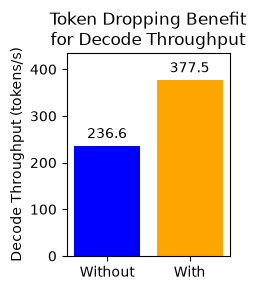

In [9]:
labels = ["Without", "With"]
data = [
    before_drop_data["metrics"]["results"]["output_tput"],
    after_drop_data["metrics"]["results"]["output_tput"],
]

fig, ax = plt.subplots(figsize=(2.5, 3))
bars = ax.bar(labels, data, color=["blue", "orange"])
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_ylabel("Decode Throughput (tokens/s)")
ax.set_title("Token Dropping Benefit\nfor Decode Throughput")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

In [ ]:
# Only close the context when done.
ctx.close()